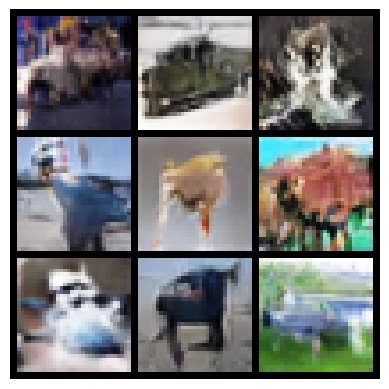

In [4]:
import torch
from gen import Generator
from torchvision import datasets, transforms
from matplotlib import pyplot as plt
from torchvision.utils import make_grid

fixed_noise = torch.randn(9, 100) 
plt.ion()

gen = Generator()
gen.load_state_dict(torch.load('../cifar_10.pth', map_location='cpu'))
gen.eval()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])
train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)


with torch.no_grad():
        fake = gen(fixed_noise).detach().cpu() 
        grid = make_grid(fake, nrow=3, padding=2,
                        normalize=True, value_range=(-1, 1))

        npimg = grid.numpy().transpose(1, 2, 0) 

        plt.clf()                 
        plt.imshow(npimg)
        plt.axis("off")
        plt.draw()         